# ![Machine Learning Lab](banner.jpg)

# Laboratorio 8 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab8.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar una Red Neuronal Convolucional (CNN) para clasificación de imágenes médicas.
2. Aplicar técnicas de preprocesamiento y aumentación de datos a imágenes.
3. Evaluar y comparar el desempeño del modelo con y sin data augmentation.

---

En esta ocasión trabajaremos con el dataset **Brain Tumor MRI Images**, que contiene imágenes de resonancia magnética cerebral clasificadas en 4 categorías: **Glioma**, **Meningioma**, **Pituitary** y **Healthy**.

Dataset: [Brain Tumor MRI Images](https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset/data)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el dataset utilizando `kagglehub`:
   ```python
   import kagglehub
   path = kagglehub.dataset_download('miadul/brain-tumor-mri-dataset')
   ```
2. Explora la estructura de carpetas del dataset y cuenta el número de imágenes por clase.
3. Visualiza al menos 3 imágenes de ejemplo de cada clase en una cuadrícula.
4. Muestra la distribución de clases en un gráfico de barras. ¿El dataset está balanceado?

---

### 2. Preprocesamiento de datos (20%)

1. Redimensiona todas las imágenes a un tamaño uniforme (por ejemplo, 150×150 píxeles).
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

---

### 3. Modelo CNN base (30%)

1. Construye una CNN con al menos 3 bloques convolucionales (Conv2D + MaxPooling2D).
2. Agrega capas Dense para la clasificación final.
3. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
4. Compila el modelo con el optimizador y función de pérdida adecuados para clasificación multiclase.
5. Entrena el modelo.
6. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).

---

### 4. Data Augmentation (30%)

1. Define una estrategia de aumentación de datos que incluya al menos 3 transformaciones (rotación, volteo, zoom, etc.).
2. Visualiza el efecto de la aumentación sobre algunas imágenes de ejemplo.
3. Construye un nuevo modelo CNN que integre las capas de aumentación.
4. Entrena el modelo.
5. Grafica las curvas de aprendizaje del modelo con aumentación.
6. Compara la precisión del modelo con y sin aumentación en el conjunto de prueba.

---

### 5. Análisis de resultados (10%)

1. Genera la matriz de confusión para ambos modelos (con y sin aumentación).
2. ¿Cuáles tipos de tumor son más difíciles de clasificar?
3. Reporta la precisión (accuracy), precisión por clase y recall por clase para el mejor modelo.

---


# Solución

In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Esto es para unos mensaje de información que me salían en CUDA

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

I0000 00:00:1776034392.099298   75066 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776034392.376613   75066 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776034394.697997   75066 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Carga y exploración de datos

### 1.1 Descarga del dataset


In [3]:
import kagglehub

path = kagglehub.dataset_download('miadul/brain-tumor-mri-dataset')
dataset_path = Path(path)
print(f'Dataset descargado en: {dataset_path}')


/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: /home/jabu/.cache/kagglehub/datasets/miadul/brain-tumor-mri-dataset/versions/1


### 1.2 Exploración de la estructura y conteo de imágenes por clase


In [4]:
class_images = {}
for root, dirs, files in os.walk(dataset_path):
    imgs = [Path(root) / f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        parts = Path(root).relative_to(dataset_path).parts
        class_images.setdefault(parts[-1], []).extend(imgs)
        indent = '  ' * (len(parts) - 1)
        print(f'{indent}{"/".join(parts)}: {len(imgs)} imágenes')

print('\nTotal por clase:')
for cls in sorted(class_images):
    print(f'  {cls}: {len(class_images[cls])} imágenes')


  brain_tumor_dataset/meningioma: 1645 imágenes
  brain_tumor_dataset/pituitary: 1757 imágenes
  brain_tumor_dataset/glioma: 1621 imágenes
  brain_tumor_dataset/healthy: 2000 imágenes
  combined/meningioma: 1645 imágenes
  combined/pituitary: 1757 imágenes
  combined/glioma: 1621 imágenes
  combined/healthy: 2000 imágenes

Total por clase:
  glioma: 3242 imágenes
  healthy: 4000 imágenes
  meningioma: 3290 imágenes
  pituitary: 3514 imágenes


### 1.3 Visualización de imágenes de ejemplo por clase


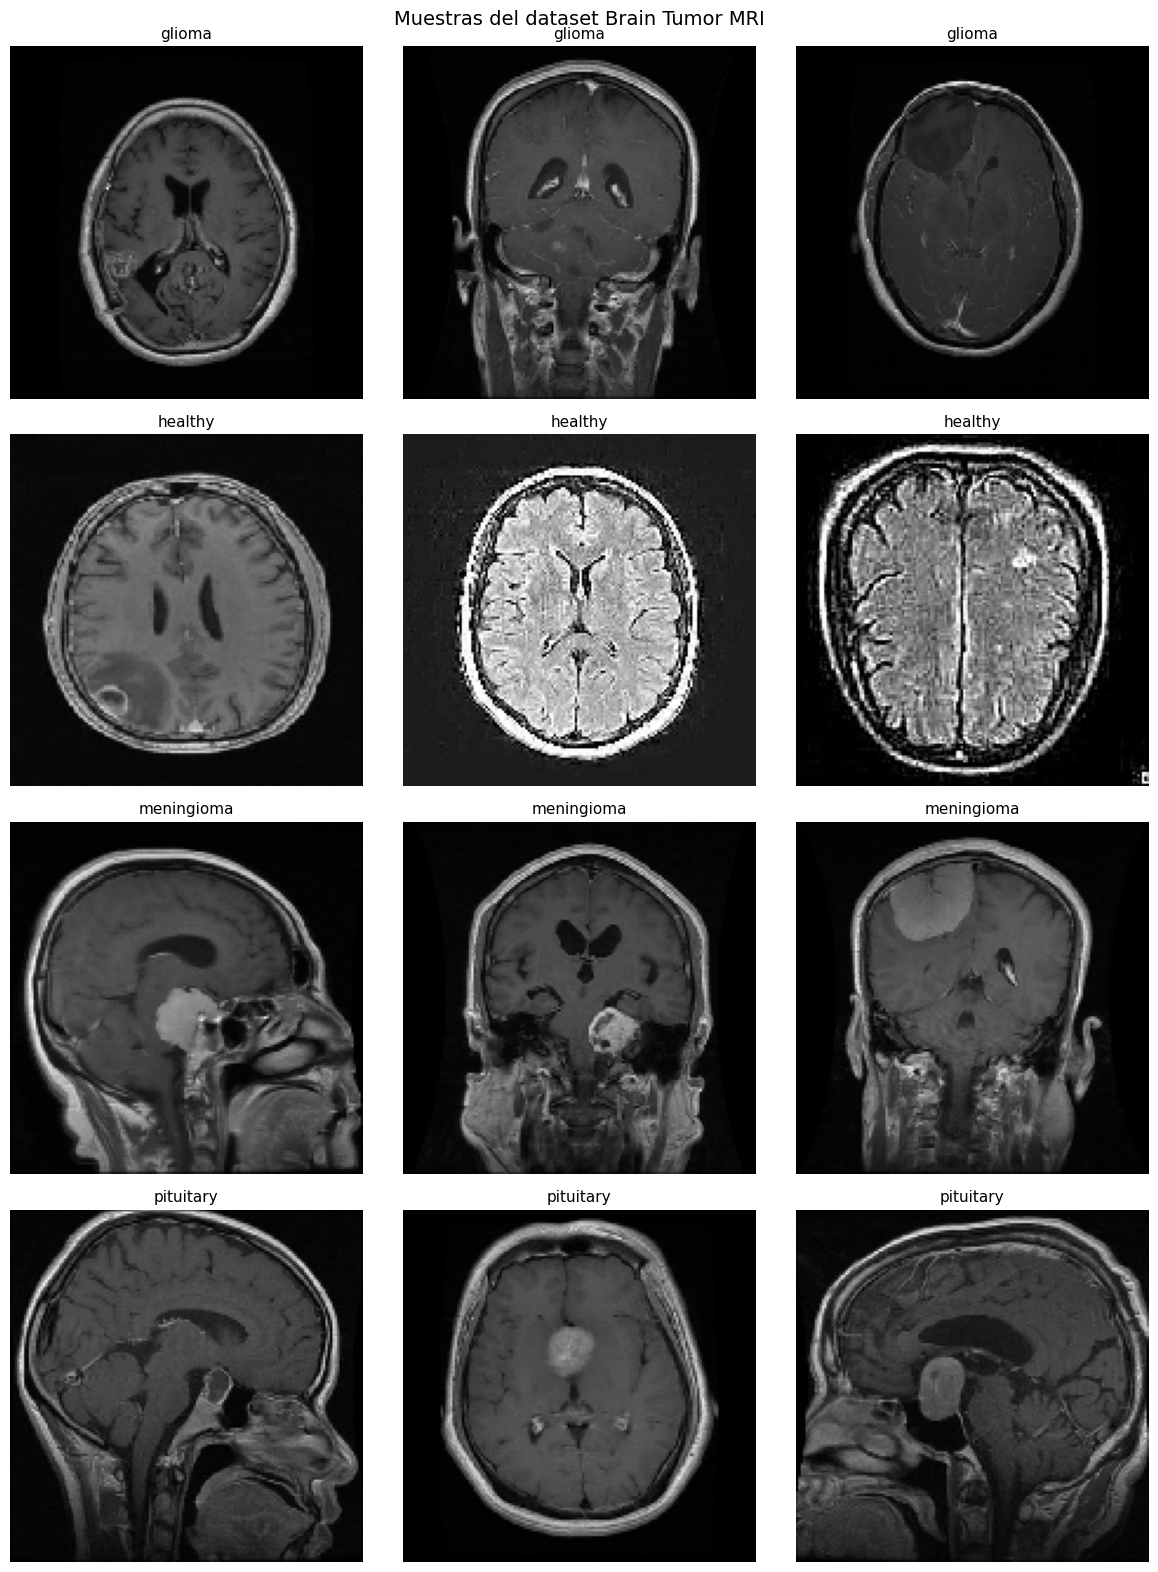

In [5]:
sorted_classes = sorted(class_images.keys())
n_classes = len(sorted_classes)

fig, axes = plt.subplots(n_classes, 3, figsize=(12, 4 * n_classes))
for row, class_name in enumerate(sorted_classes):
    for col, img_path in enumerate(random.sample(class_images[class_name], 3)):
        img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name, fontsize=11)
        axes[row, col].axis('off')

plt.suptitle('Muestras del dataset Brain Tumor MRI', fontsize=14)
plt.tight_layout()
plt.show()


### 1.4 Distribución de clases


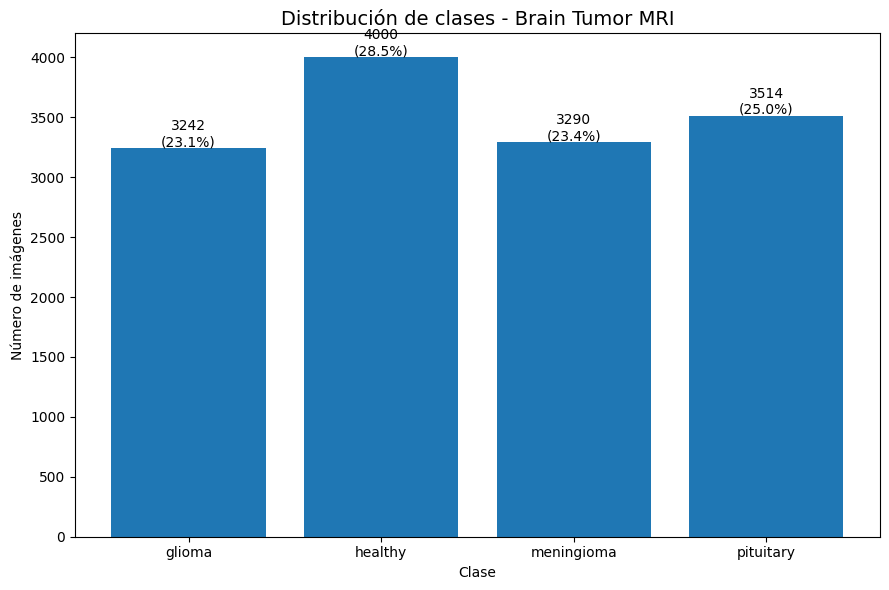

Ratio máx/mín: 1.23 - Dataset balanceado


In [8]:
class_totals = {cls: len(class_images[cls]) for cls in sorted_classes}
total_img = sum(class_totals.values())

plt.figure(figsize=(9, 6))
bars = plt.bar(class_totals.keys(), class_totals.values())
for bar, count in zip(bars, class_totals.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
             f'{count}\n({100 * count / total_img:.1f}%)', ha='center', fontsize=10)
plt.title('Distribución de clases - Brain Tumor MRI', fontsize=14)
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.show()

ratio = max(class_totals.values()) / min(class_totals.values())
print(f'Ratio máx/mín: {ratio:.2f} - {"Dataset balanceado" if ratio < 1.5 else "Dataset desbalanceado"}')


## 2. Preprocesamiento de datos


In [10]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

combined_dir = dataset_path / 'combined'
for class_name, images in class_images.items():
    (combined_dir / class_name).mkdir(parents=True, exist_ok=True)
    for img_path in images:
        dest = combined_dir / class_name / f'{img_path.parent.name}_{img_path.name}'
        if not dest.exists():
            shutil.copy2(img_path, dest)

full_ds = tf.keras.utils.image_dataset_from_directory(
    combined_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
    shuffle=True
)
class_names = full_ds.class_names
print(f'Clases detectadas: {class_names}')

rescale = tf.keras.layers.Rescaling(1.0 / 255)
full_ds = full_ds.map(lambda x, y: (rescale(x), y))

total_files = sum(
    1 for cls_dir in combined_dir.iterdir() if cls_dir.is_dir()
    for f in cls_dir.iterdir() if f.is_file()
)
train_batches = int(total_files * 0.70) // BATCH_SIZE
val_batches = int(total_files * 0.15) // BATCH_SIZE

AUTOTUNE = tf.data.AUTOTUNE
train_ds = full_ds.take(train_batches).cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = full_ds.skip(train_batches).take(val_batches).cache().prefetch(AUTOTUNE)
test_ds = full_ds.skip(train_batches + val_batches).prefetch(AUTOTUNE)

print(f'Total: {total_files} imágenes')
print(f'Train: {train_batches * BATCH_SIZE} imágenes ({train_batches} batches)')
print(f'Validación: {val_batches * BATCH_SIZE} imágenes ({val_batches} batches)')
print(f'Test: {total_files - (train_batches + val_batches) * BATCH_SIZE} imágenes')


Found 14046 files belonging to 4 classes.
Clases detectadas: ['glioma', 'healthy', 'meningioma', 'pituitary']
Total: 14046 imágenes
Train: 9824 imágenes (307 batches)
Validación: 2080 imágenes (65 batches)
Test: 2142 imágenes


## 3. Modelo CNN Base


### 3.1 y 3.2 - CNN con 3 bloques convolucionales

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

### 3.3 Resumen del modelo y conteo de parámetros

In [15]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,260 (40.86 MB)

 Trainable params: 10,711,812 (40.86 MB)

 Non-trainable params: 448 (1.75 KB)

### 3.4 Compilar el modelo

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 3.5 Entrenar el modelo

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20


I0000 00:00:1776035936.365087   76604 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37513__.56


307/307 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.6633 - loss: 1.7519 - val_accuracy: 0.5442 - val_loss: 3.5261
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7363 - loss: 0.6656 - val_accuracy: 0.8471 - val_loss: 0.5123
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7763 - loss: 0.5663 - val_accuracy: 0.8087 - val_loss: 0.4584
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8157 - loss: 0.4882 - val_accuracy: 0.8933 - val_loss: 0.2702
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8400 - loss: 0.4154 - val_accuracy: 0.9341 - val_loss: 0.1832
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8666 - loss: 0.3483 - val_accuracy: 0.9043 - val_loss: 0.2099
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8805 - loss: 0.3136 - val_accuracy: 0.9192 - val_loss: 0.2089
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8962 - loss: 0.2736 - val_accuracy

### 3.6. Gráficas de pérdida y precisión

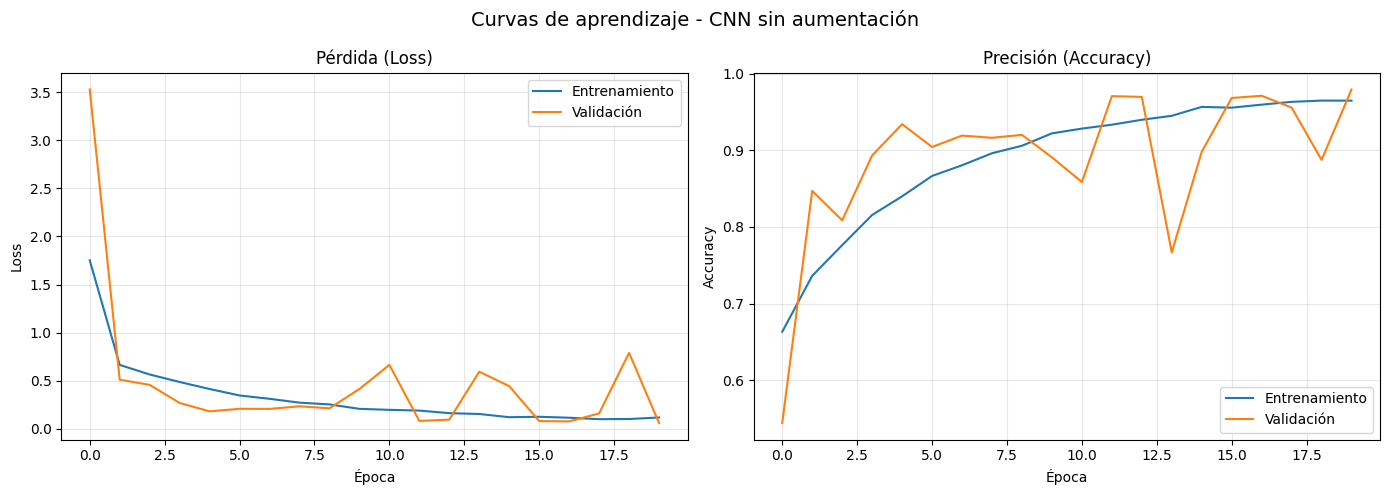

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Entrenamiento')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_title('Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_title('Precisión (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje - CNN sin aumentación', fontsize=14)
plt.tight_layout()
plt.show()


## 4. Data Augmentation


### 4.1. Estrategia de aumentación de datos con 3 transformaciones

In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
])


### 4.2. Visualización del efecto de la aumentación

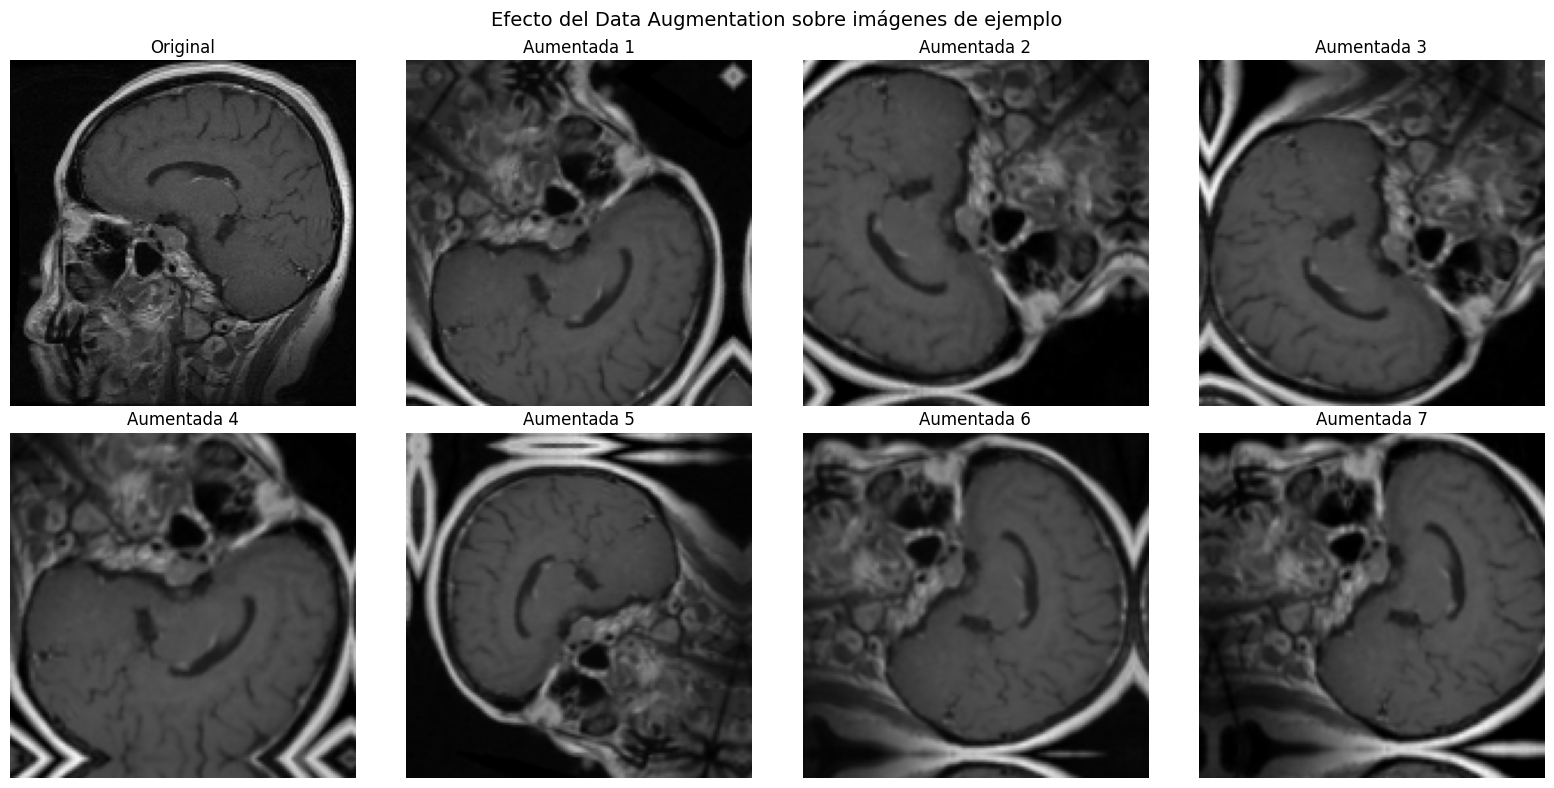

In [ ]:
for images, _ in train_ds.take(1):
    sample_image = images[0]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes[0, 0].imshow(sample_image.numpy())
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')

    for i, ax in enumerate(axes.flatten()[1:], 1):
        aug_img = data_augmentation(tf.expand_dims(sample_image, 0), training=True)[0]
        ax.imshow(np.clip(aug_img.numpy(), 0, 1))
        ax.set_title(f'Aumentada {i}')
        ax.axis('off')
        
    plt.suptitle('Efecto del Data Augmentation sobre imágenes de ejemplo', fontsize=14)
    plt.tight_layout()
    plt.show()
    break


### 4.3. Entrenar el modelo con aumentación de datos

In [22]:
model_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),

    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 150, 150, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,260 (40.86 MB)

 Trainable params: 10,711,812 (40.86 MB)

 Non-trainable params: 448 (1.75 KB)

### 4.4. Entrenar el modelo con aumentación de datos

In [23]:
history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20


307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.4732 - loss: 2.1593 - val_accuracy: 0.4010 - val_loss: 3.0712
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.5392 - loss: 1.0595 - val_accuracy: 0.6510 - val_loss: 0.8583
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.5608 - loss: 1.0170 - val_accuracy: 0.3558 - val_loss: 4.1577
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.5838 - loss: 0.9624 - val_accuracy: 0.4880 - val_loss: 1.8650
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.5959 - loss: 0.9345 - val_accuracy: 0.3558 - val_loss: 3.4367
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.6077 - loss: 0.9282 - val_accuracy: 0.5514 - val_loss: 1.3379
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.6105 - loss: 0.8811 - val_accuracy: 0.5808 - val_loss: 1.2111
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6283 - loss: 0.8740 - val_accurac

### 4.5. Curvas de aprendizaje con aumentación

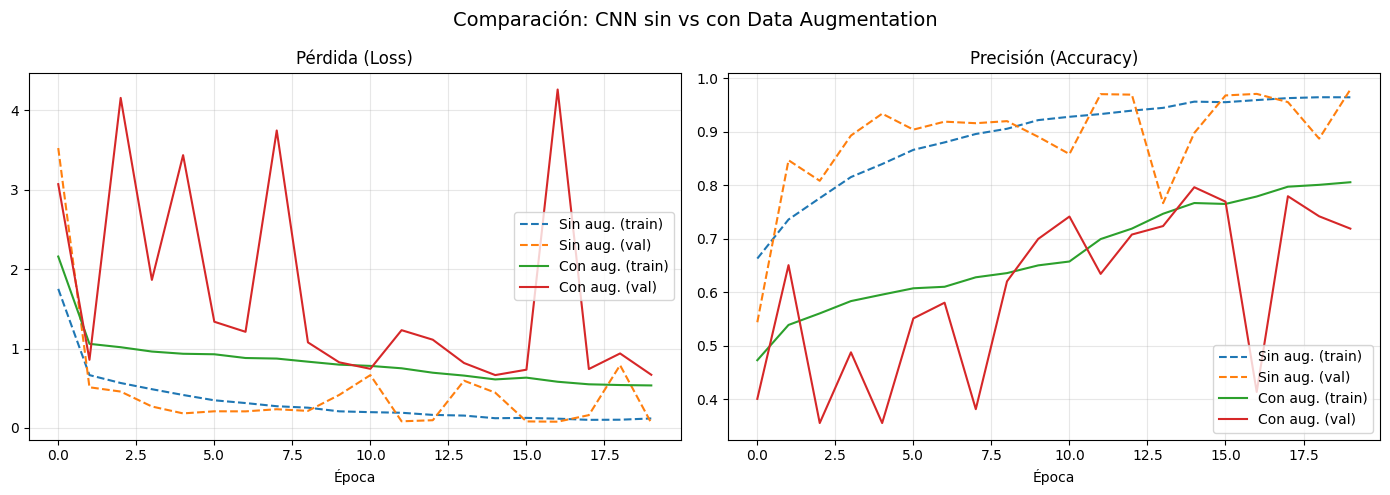

Sin aumentación: Test Accuracy: 0.9776, Loss: 0.0768
Con aumentación: Test Accuracy: 0.7185, Loss: 0.6452


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Sin aug. (train)', linestyle='--')
axes[0].plot(history.history['val_loss'], label='Sin aug. (val)', linestyle='--')
axes[0].plot(history_aug.history['loss'], label='Con aug. (train)')
axes[0].plot(history_aug.history['val_loss'], label='Con aug. (val)')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Sin aug. (train)', linestyle='--')
axes[1].plot(history.history['val_accuracy'], label='Sin aug. (val)', linestyle='--')
axes[1].plot(history_aug.history['accuracy'], label='Con aug. (train)')
axes[1].plot(history_aug.history['val_accuracy'], label='Con aug. (val)')
axes[1].set_title('Precisión (Accuracy)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación: CNN sin vs con Data Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
test_loss_aug, test_acc_aug = model_aug.evaluate(test_ds, verbose=0)
print(f'Sin aumentación: Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}')
print(f'Con aumentación: Test Accuracy: {test_acc_aug:.4f}, Loss: {test_loss_aug:.4f}')


## 5. Análisis de resultados


### 5.1. Matriz de confusión para ambos modelos

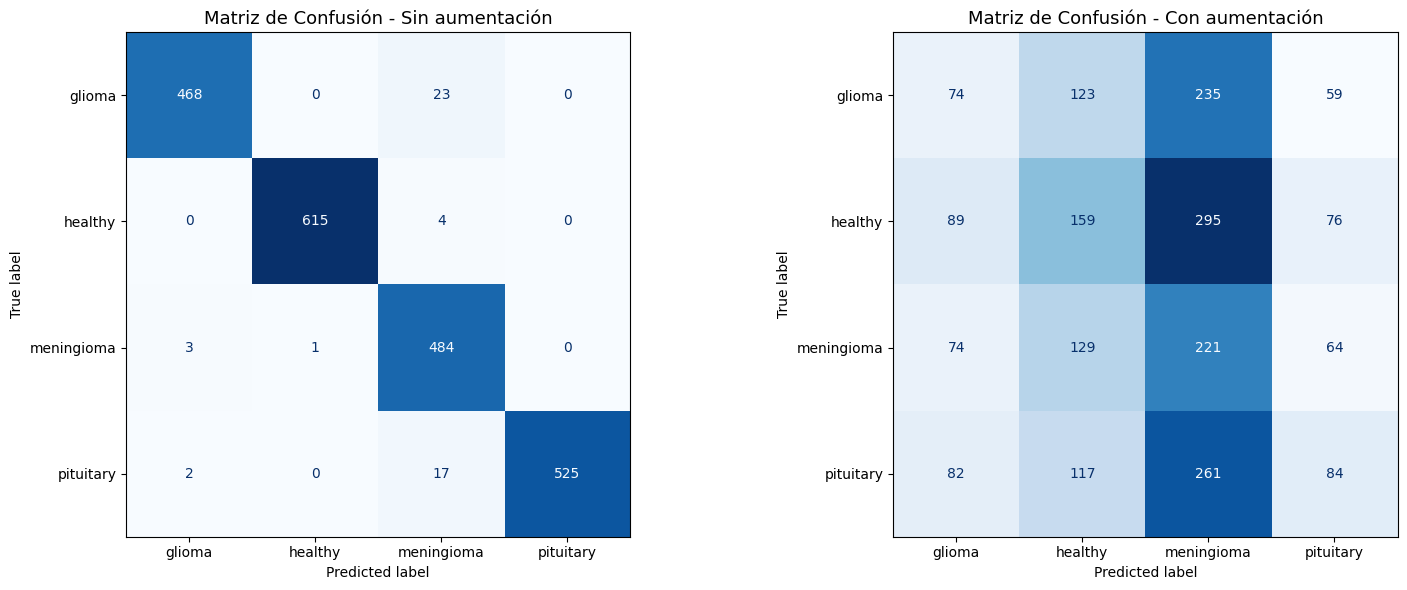

In [26]:
def collect_predictions(mdl, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = mdl.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

y_true, y_pred_base = collect_predictions(model, test_ds)
_, y_pred_aug = collect_predictions(model_aug, test_ds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_p, title in zip(axes,
                           [y_pred_base, y_pred_aug],
                           ['Sin aumentación', 'Con aumentación']):
    cm = confusion_matrix(y_true, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión - {title}', fontsize=13)
    
plt.tight_layout()
plt.show()


### 5.2. y 5.3. Clases más difíciles de clasificar; accuracy, precisión y recall por clase

In [30]:
best_preds = y_pred_aug if test_acc_aug >= test_acc else y_pred_base
best_name = 'con aumentación' if test_acc_aug >= test_acc else 'sin aumentación'

print(f'Reporte del mejor modelo ({best_name}):')
print(f'Accuracy general: {max(test_acc_aug, test_acc):.4f}\n')
print(classification_report(y_true, best_preds, target_names=class_names, digits=4))


Reporte del mejor modelo (sin aumentación):
Accuracy general: 0.9302

              precision    recall  f1-score   support

      glioma     0.9528    0.8899    0.9203       227
     healthy     0.9306    0.9908    0.9598       325
  meningioma     0.8636    0.8604    0.8620       265
   pituitary     0.9715    0.9545    0.9630       286

    accuracy                         0.9293      1103
   macro avg     0.9297    0.9239    0.9263      1103
weighted avg     0.9297    0.9293    0.9290      1103



A partir de las matrices de confusión, las clases más difíciles de clasificar son aquellas con mayor número de predicciones incorrectas (filas/columnas con valores altos fuera de la diagonal principal). También las que tienen el menor recall son las que no se detectan muy bien.

Basado en la tabla anterior, las categorías meningioma y glioma tienden a confundirse entre sí, ya que ambas son masas tumorales con apariencias radiológicas similares en MRI. La clase *healthy* (cerebro sano) suele ser la más fácil de distinguir, ya que la ausencia de masa tumoral presenta patrones claramente diferentes.

También cabe resaltar que la aumentación de los datos por rotación fue contraproducente y lo único que hizo fue empeorar el modelo. Llevar a cabo rotaciones de MRI no tiene mucho sentido ya que la orientación de la imagen es un factor importante para la clasificación, y rotar las imágenes puede introducir variaciones que no son representativas de casos reales.